In [1]:
# assign directory
import git
from pathlib import Path
import os
ROOT_DIR = Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
os.chdir(os.path.join(ROOT_DIR, "utilities"))
# from transform import *
from transform_audio import *
# from plotting import *
os.chdir(os.path.join(ROOT_DIR, "dataset-preparation"))

respiratory_dir = os.path.join(ROOT_DIR, 'raw-data', 'respiratory')
data_dir = os.path.join(respiratory_dir, 'respiratory_cycles')
# iterate over files in that directory
file_list = [os.path.join(data_dir, filename) for filename in os.listdir(data_dir) if filename != ".DS_Store"]
file_names = os.listdir(data_dir)

In [2]:
# erblet
transform_list(erblet_file, file_list, file_names)

Computing and exporting coefficients:   0%|          | 0/5409 [00:00<?, ?it/s]

In [3]:
# fourier
max_n = max(map(lambda f: len(wavfile.read(f)[1]), file_list))
transform_list(fft_file, file_list, file_names, n=max_n)

Computing and exporting coefficients:   0%|          | 0/5409 [00:00<?, ?it/s]

In [2]:
# short-time fourier
transform_list(stft_file, file_list, file_names)

Computing and exporting coefficients:   0%|          | 0/5409 [00:00<?, ?it/s]

In [2]:
# continuous wavelet
np.random.seed(42)
p = 25 # subsample percentage
subset_indices = np.random.choice(len(file_list), size=int(len(file_list) * p/100), replace=False)
file_list_subsample = [file_list[i] for i in subset_indices]
file_names_subsample = [file_names[i] for i in subset_indices]
transform_list(cwt_file, file_list_subsample, file_names_subsample, 
               low_freq=10, high_freq=20000, num_scales=30, affix=f'cwt-sub{p}')

Computing and exporting coefficients:   0%|          | 0/1352 [00:00<?, ?it/s]

## Banding

In [2]:
def visualize_bands(bands, title=""):
    plt.figure(figsize=(12, 2))
    colors = ['lightcoral', 'indianred']
    
    # Check if bands list is not empty
    if not bands:
        print(f"Warning: Cannot visualize bands for '{title}' because the band list is empty.")
        return

    for i, (start, end) in enumerate(bands):
        plt.broken_barh([(start, end - start)], (0, 1), facecolors=colors[i%2])
    
    plt.xlabel('Frequency Index')
    plt.ylabel('Bands')
    plt.title(title)
    plt.yticks([])
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()

In [ ]:
# # usage template
# coefs_by_freq = load_coefs_by_freq(coefs_npz_path, *args, cache=True)
# bands = freq_band_groupings(coefs_npz_path, *args, cache=True)
# coef_groups = group_coefs_by_band(coefs_by_freq, bands)

In [3]:
# erblet
coefs_npz_path = os.path.join(respiratory_dir, 'transforms', 'erb_coefs.npz')
freqs_npy_path = os.path.join(respiratory_dir, 'transforms', 'erb_freqs.npy')

# TODO: standardize this
freqs = np.load(freqs_npy_path)
avg_lengths = np.zeros_like(freqs, dtype=int)
with np.load(coefs_npz_path, allow_pickle=True) as coefs_npz:
    for file in coefs_npz:
        avg_lengths += np.array([len(c) for c in coefs_npz[file]])
    avg_lengths //= len(coefs_npz)

# coefs_by_freq = load_coefs_by_freq(
#     coefs_npz_path, 
#     batch_size=22,
#     subsample_every=-(-avg_lengths // 500),
#     debug=True,
#     cache=True
# )
bands = freq_band_groupings(
    coefs_npz_path,
    batch_size=11,
    subsample_every=-(-avg_lengths // 500),
    presplit_depth=1,
    debug=True
)
bands

[0, 22) ~ [22, 44): presplit
  [0, 11) ~ [11, 22): 0.25551, 0.0
    [0, 5) ~ [5, 11): 0.19981, 0.0
      [0, 2) ~ [2, 5): 0.16450, 0.0
        [0, 1) ~ [1, 2): 0.24822, 0.0
        [2, 3) ~ [3, 5): 0.12305, 0.0
          [3, 4) ~ [4, 5): 0.06314, 0.0
      [5, 8) ~ [8, 11): 0.12393, 0.0
        [5, 6) ~ [6, 8): 0.08760, 0.0
          [6, 7) ~ [7, 8): 0.04437, 0.0
        [8, 9) ~ [9, 11): 0.04781, 0.0
    [11, 16) ~ [16, 22): 0.11219, 0.0
      [11, 13) ~ [13, 16): 0.06472, 0.0
        [11, 12) ~ [12, 13): 0.02747, 0.0
        [13, 14) ~ [14, 16): 0.03487, 0.0
      [16, 19) ~ [19, 22): 0.06278, 0.0
        [16, 17) ~ [17, 19): 0.02563, 0.0
        [19, 20) ~ [20, 22): 0.03583, 0.0
  [22, 33) ~ [33, 44): 0.09614, 0.0
    [22, 27) ~ [27, 33): 0.05221, 0.0
      [22, 24) ~ [24, 27): 0.02944, 0.0
      [27, 30) ~ [30, 33): 0.02402, 0.0
    [33, 38) ~ [38, 44): 0.08828, 0.0
      [33, 35) ~ [35, 38): 0.02146, 0.0
      [38, 41) ~ [41, 44): 0.16725, 0.0
        [38, 39) ~ [39, 41): 0.00259,

[(0, 1),
 (1, 2),
 (2, 3),
 (3, 4),
 (4, 5),
 (5, 6),
 (6, 8),
 (8, 11),
 (11, 13),
 (13, 16),
 (16, 19),
 (19, 22),
 (22, 27),
 (27, 33),
 (33, 38),
 (38, 41),
 (41, 42),
 (42, 43),
 (43, 44)]

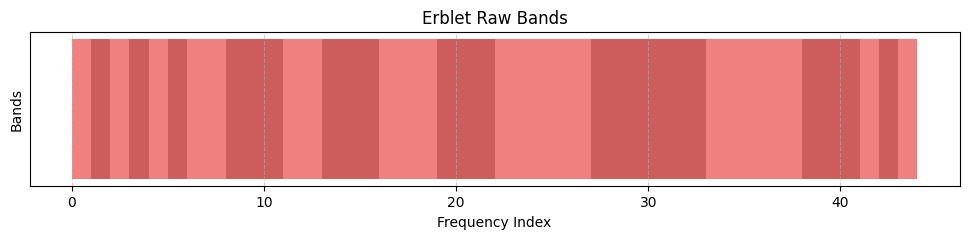

In [4]:
visualize_bands(bands, 'Erblet Raw Bands')

In [5]:
# short-time fourier
coefs_npz_path = os.path.join(respiratory_dir, 'transforms', 'stft_coefs.npz')

coefs_by_freq = load_coefs_by_freq(
    coefs_npz_path, 
    batch_size=None,
    subsample_every=10,
    debug=True,
    cache=True
)
bands = freq_band_groupings(
    coefs_npz_path,
    subsample_every=10,
    presplit_depth=1,
    debug=True,
    cache=True
)
bands

[0, 256) ~ [256, 513): presplit
  [0, 128) ~ [128, 256): 0.12187, 0.0
    [0, 64) ~ [64, 128): 0.15801, 0.0
      [0, 32) ~ [32, 64): 0.18964, 0.0
        [0, 16) ~ [16, 32): 0.20581, 0.0
          [0, 8) ~ [8, 16): 0.21836, 0.0
            [0, 4) ~ [4, 8): 0.20516, 0.0
              [0, 2) ~ [2, 4): 0.12520, 0.0
                [0, 1) ~ [1, 2): 0.25020, 0.0
                [2, 3) ~ [3, 4): 0.10414, 0.0
              [4, 6) ~ [6, 8): 0.09230, 0.0
                [4, 5) ~ [5, 6): 0.06231, 0.0
                [6, 7) ~ [7, 8): 0.04113, 0.0
            [8, 12) ~ [12, 16): 0.06676, 0.0
              [8, 10) ~ [10, 12): 0.04151, 0.0
              [12, 14) ~ [14, 16): 0.02746, 0.0
          [16, 24) ~ [24, 32): 0.05699, 0.0
            [16, 20) ~ [20, 24): 0.03436, 0.0
            [24, 28) ~ [28, 32): 0.01659, 6.3760319600207345e-239
        [32, 48) ~ [48, 64): 0.05322, 0.0
          [32, 40) ~ [40, 48): 0.03972, 0.0
          [48, 56) ~ [56, 64): 0.01477, 0.0
      [64, 96) ~ [96, 128): 0.0

[(0, 1),
 (1, 2),
 (2, 3),
 (3, 4),
 (4, 5),
 (5, 6),
 (6, 8),
 (8, 12),
 (12, 16),
 (16, 24),
 (24, 32),
 (32, 48),
 (48, 64),
 (64, 128),
 (128, 256),
 (256, 513)]

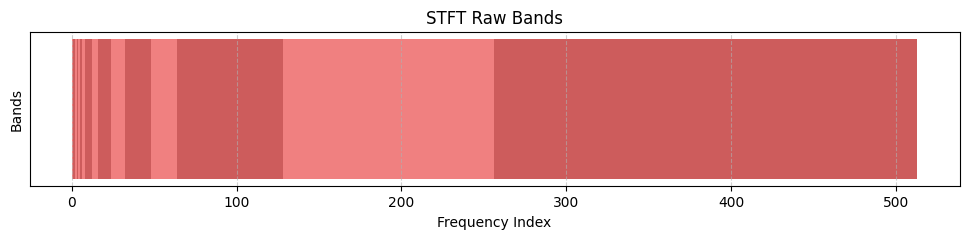

In [6]:
visualize_bands(bands, 'STFT Raw Bands')

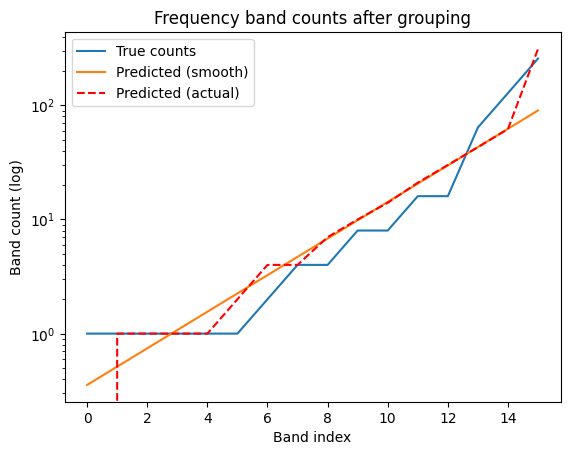

[(0, 0),
 (0, 1),
 (1, 2),
 (2, 3),
 (3, 4),
 (4, 6),
 (6, 10),
 (10, 14),
 (14, 21),
 (21, 31),
 (31, 45),
 (45, 66),
 (66, 96),
 (96, 139),
 (139, 201),
 (201, 513)]

In [7]:
geometric_count_bands(bands, visualize=True)

In [8]:
# fourier
coefs_npz_path = os.path.join(respiratory_dir, 'transforms', 'fft_coefs.npz')

coefs_by_freq = load_coefs_by_freq(
    coefs_npz_path, 
    batch_size=None,
    subsample_every=10,
    debug=True,
    cache=True
)
bands = freq_band_groupings(
    coefs_npz_path,
    batch_size=None,
    subsample_every=10,
    presplit_depth=1,
    debug=False,
    cache=True
)
bands

[(0, 215),
 (215, 322),
 (322, 430),
 (430, 645),
 (645, 861),
 (861, 1291),
 (1291, 1722),
 (1722, 2583),
 (2583, 3444),
 (3444, 5166),
 (5166, 6889),
 (6889, 10333),
 (10333, 13778),
 (13778, 27557),
 (27557, 55114),
 (55114, 110228)]

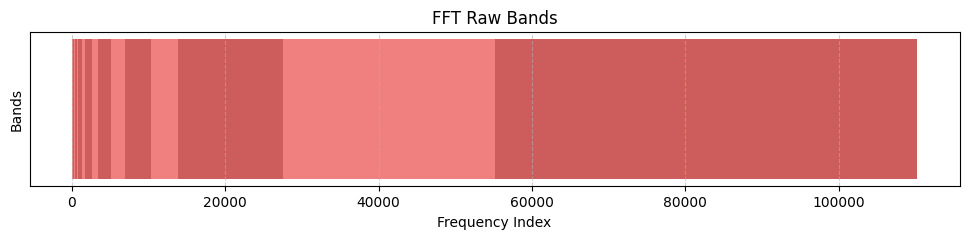

In [9]:
visualize_bands(bands, 'FFT Raw Bands')

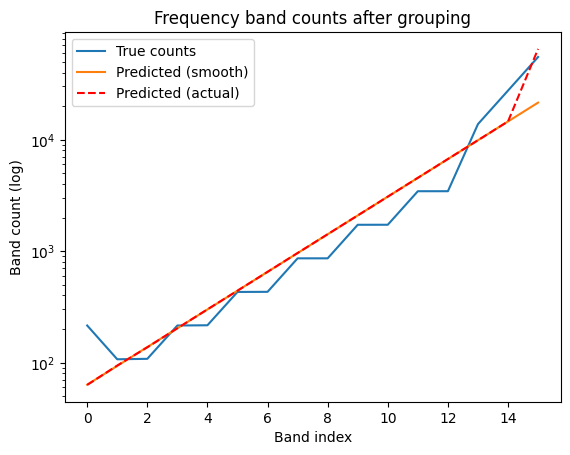

[(0, 63),
 (63, 157),
 (157, 294),
 (294, 497),
 (497, 797),
 (797, 1238),
 (1238, 1889),
 (1889, 2850),
 (2850, 4266),
 (4266, 6354),
 (6354, 9433),
 (9433, 13974),
 (13974, 20671),
 (20671, 30547),
 (30547, 45110),
 (45110, 110228)]

In [10]:
geometric_count_bands(bands, visualize=True)